In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import keras
from keras import layers

# Charger le CSV Airline Passengers
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

print(f"Shape : {df.shape}")
print(f"Colonnes : {df.columns.tolist()}")
print(f"\nAperçu :")
print(df.head(10))
print(f"\nMin : {df['Passengers'].min()}, Max : {df['Passengers'].max()}")

Shape : (144, 2)
Colonnes : ['Month', 'Passengers']

Aperçu :
     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121
5  1949-06         135
6  1949-07         148
7  1949-08         148
8  1949-09         136
9  1949-10         119

Min : 104, Max : 622


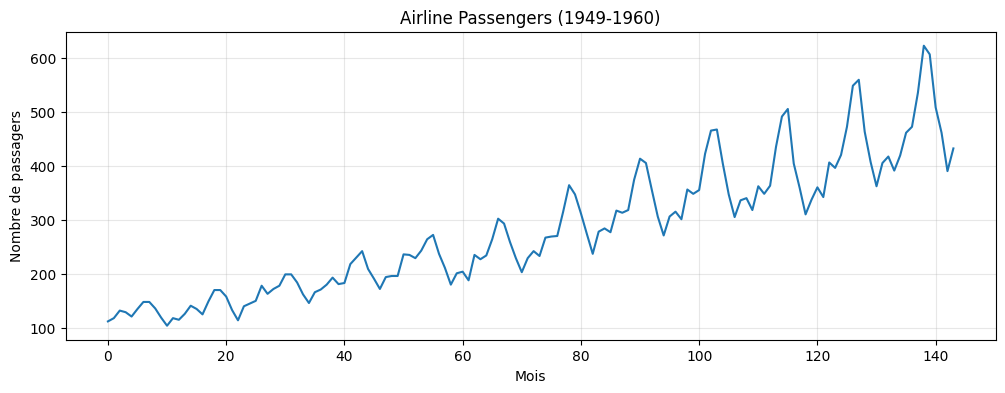

In [3]:
plt.figure(figsize=(12, 4))
plt.plot(df['Passengers'].values)
plt.title("Airline Passengers (1949-1960)")
plt.xlabel("Mois")
plt.ylabel("Nombre de passagers")
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
# Extraire les valeurs et convertir en float32
data = df['Passengers'].values.astype('float32').reshape(-1, 1)

# Normaliser entre 0 et 1 (le LSTM est sensible aux grandes valeurs)
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

# Split temporel 67/33
split = int(len(data_scaled) * 0.67)
train = data_scaled[:split]
test = data_scaled[split:]

print(f"Data scaled — min : {data_scaled.min():.2f}, max : {data_scaled.max():.2f}")
print(f"Train : {train.shape[0]} points")
print(f"Test  : {test.shape[0]} points")
print(f"Split à l'index {split} (mois {df['Month'].iloc[split]})")

Data scaled — min : 0.00, max : 1.00
Train : 96 points
Test  : 48 points
Split à l'index 96 (mois 1957-01)


In [5]:
def create_dataset(dataset, window_size=12):
    """
    Transforme une série 1D en paires (X, y) via sliding window.
    Retourne X : (N - window_size, window_size, 1), y : (N - window_size,)
    """
    X, y = [], []
    for i in range(len(dataset) - window_size):
        X.append(dataset[i:i + window_size, 0])
        y.append(dataset[i + window_size, 0])
    X = np.array(X).reshape(-1, window_size, 1)
    y = np.array(y)
    return X, y

WINDOW_SIZE = 12

X_train, y_train = create_dataset(train, WINDOW_SIZE)
X_test, y_test = create_dataset(test, WINDOW_SIZE)

print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_test  : {y_test.shape}")

X_train : (84, 12, 1)
y_train : (84,)
X_test  : (36, 12, 1)
y_test  : (36,)


In [6]:
# Happy path : vérification des shapes et normalisation
assert X_train.shape == (84, 12, 1), f"Shape X_train incorrecte : {X_train.shape}"
assert y_train.shape == (84,), f"Shape y_train incorrecte : {y_train.shape}"
assert data_scaled.min() >= 0 and data_scaled.max() <= 1, "Normalisation hors [0,1]"
print("✅ Happy path OK : shapes correctes, normalisation [0,1]")

# Edge case : window_size=1
X_edge, y_edge = create_dataset(train, window_size=1)
print(f"\n🔍 Edge case window=1 : X={X_edge.shape}, y={y_edge.shape}")
print(f"   Avec 1 seul step de contexte, le modèle ne peut que copier la valeur précédente")

# Adversarial : NaN dans le dataset
data_nan = train.copy()
data_nan[5, 0] = np.nan
X_nan, y_nan = create_dataset(data_nan, WINDOW_SIZE)
has_nan = np.isnan(X_nan).any() or np.isnan(y_nan).any()
print(f"\n⚠️  Adversarial NaN : présence de NaN dans le dataset = {has_nan}")
print(f"   Protection possible : ajouter un assert not np.isnan(dataset).any() en début de create_dataset")

✅ Happy path OK : shapes correctes, normalisation [0,1]

🔍 Edge case window=1 : X=(95, 1, 1), y=(95,)
   Avec 1 seul step de contexte, le modèle ne peut que copier la valeur précédente

⚠️  Adversarial NaN : présence de NaN dans le dataset = True
   Protection possible : ajouter un assert not np.isnan(dataset).any() en début de create_dataset


In [7]:
model = keras.Sequential([
    layers.LSTM(64, input_shape=(WINDOW_SIZE, 1)),
    layers.Dropout(0.2),
    layers.Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.0231 - mae: 0.1182 - val_loss: 0.0200 - val_mae: 0.1142
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0078 - mae: 0.0767 - val_loss: 0.0149 - val_mae: 0.0997
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0052 - mae: 0.0537 - val_loss: 0.0274 - val_mae: 0.1382
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0049 - mae: 0.0537 - val_loss: 0.0147 - val_mae: 0.1009
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0050 - mae: 0.0574 - val_loss: 0.0131 - val_mae: 0.0970
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0035 - mae: 0.0445 - val_loss: 0.0145 - val_mae: 0.1013
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0041 - mae: 0.0499 - val_loss: 0.0118 - val_mae: 0.0918
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0038 - mae: 0.0476 - val_loss: 0.0122 - val_mae: 0.0938
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - lo

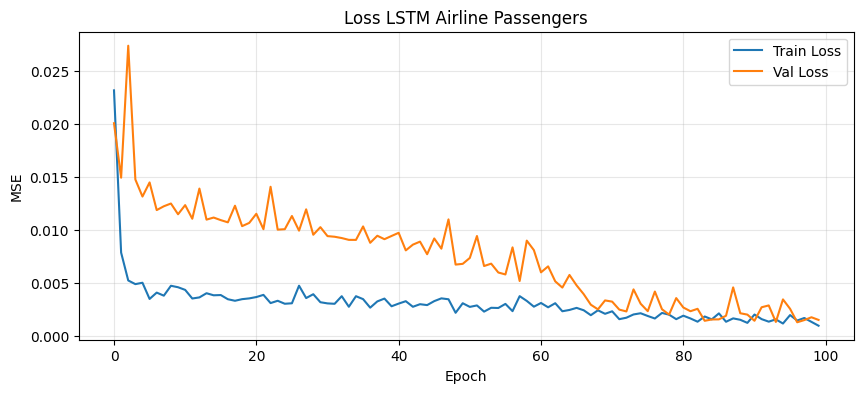

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss LSTM Airline Passengers")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
from sklearn.metrics import mean_squared_error

# Prédictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# Dénormaliser
train_pred_inv = scaler.inverse_transform(train_pred)
test_pred_inv = scaler.inverse_transform(test_pred)
y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# RMSE en unité passagers
rmse_train = np.sqrt(mean_squared_error(y_train_inv, train_pred_inv))
rmse_test = np.sqrt(mean_squared_error(y_test_inv, test_pred_inv))

print(f"RMSE Train : {rmse_train:.2f} passagers")
print(f"RMSE Test  : {rmse_test:.2f} passagers")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
RMSE Train : 16.65 passagers
RMSE Test  : 37.53 passagers


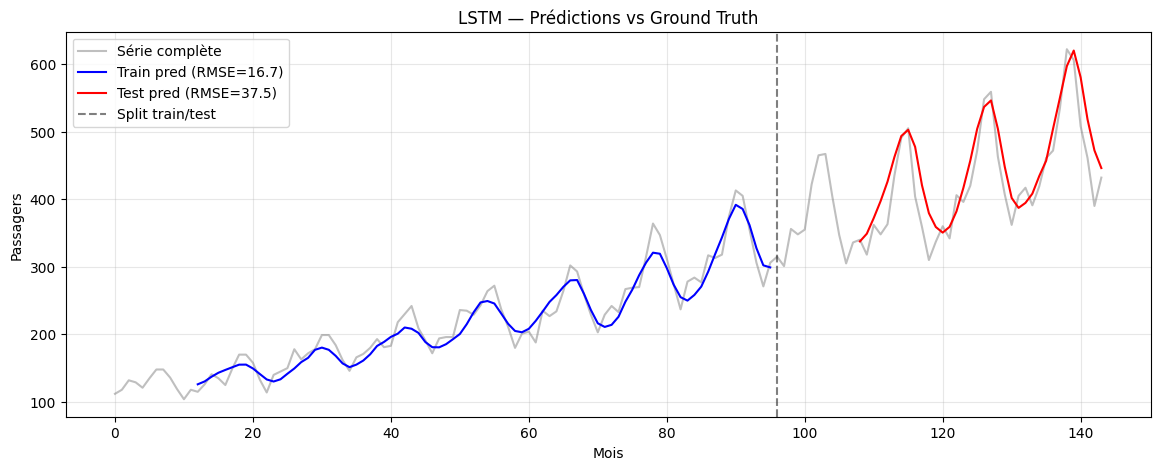

In [11]:
plt.figure(figsize=(14, 5))

# Série complète en gris
plt.plot(df['Passengers'].values, color='gray', alpha=0.5, label='Série complète')

# Prédictions train (décalées de WINDOW_SIZE car les 12 premiers mois servent d'input)
train_range = range(WINDOW_SIZE, WINDOW_SIZE + len(train_pred_inv))
plt.plot(train_range, train_pred_inv, color='blue', label=f'Train pred (RMSE={rmse_train:.1f})')

# Prédictions test
test_range = range(split + WINDOW_SIZE, split + WINDOW_SIZE + len(test_pred_inv))
plt.plot(test_range, test_pred_inv, color='red', label=f'Test pred (RMSE={rmse_test:.1f})')

plt.axvline(x=split, color='black', linestyle='--', alpha=0.5, label='Split train/test')
plt.title("LSTM — Prédictions vs Ground Truth")
plt.xlabel("Mois")
plt.ylabel("Passagers")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
model.save('airline_lstm.keras')
print("✅ Modèle Airline LSTM sauvegardé : airline_lstm.keras")

print(f"\n📊 RMSE Test : {rmse_test:.2f} passagers")
if rmse_test < 50:
    print("✅ Happy path : RMSE < 50, excellent !")
elif rmse_test < 70:
    print("✅ Happy path : RMSE < 70, bon résultat")
else:
    print("⚠️  RMSE > 70, le modèle pourrait être amélioré")

print(f"📈 Epochs effectuées : {len(history.history['loss'])}")
print(f"📉 Val loss finale : {history.history['val_loss'][-1]:.6f}")

✅ Modèle Airline LSTM sauvegardé : airline_lstm.keras

📊 RMSE Test : 37.53 passagers
✅ Happy path : RMSE < 50, excellent !
📈 Epochs effectuées : 100
📉 Val loss finale : 0.001483
